In [1]:
# eda05: same pipeline as eda04 (weighted avg, chain, composite, crop); display via eda04_radial.pkl
import math
import numpy as np
import torch
import pickle
import tqdm
from pathlib import Path
from PIL import Image
import enum
from dataclasses import dataclass

class MoonInfoOrigin(enum.Enum):
    DIRECT = 0
    INTERPOLATED = 1

@dataclass
class ImageInfo:
    path: Path
    width: int
    height: int
    avg_brightness: float
    timestamp: float
    exposure_time: float
    moon: tuple[float, float, float] = None
    moon_info_origin: MoonInfoOrigin = None
    moon_pos_std_px: float = None

PKL_DIR = "/home/slavik/tmp"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load eda02 (exposure_groups, opt_results) and eda03 (cross_reg, gamma_by_pair)
with open(f"{PKL_DIR}/eda02.pkl", "rb") as fd:
    exposure_groups = pickle.load(fd)
    reg = pickle.load(fd)
    opt_results = pickle.load(fd)
with open(f"{PKL_DIR}/eda03.pkl", "rb") as fd:
    cross_reg = pickle.load(fd)
    gamma_by_pair = pickle.load(fd)

exposure_times_sorted = sorted(exposure_groups.keys())
t_ref = exposure_times_sorted[0]

def moon_median(group):
    centers_i = [ii.moon[0] for ii in group]
    centers_j = [ii.moon[1] for ii in group]
    radii = [ii.moon[2] for ii in group]
    return (float(np.median(centers_i)), float(np.median(centers_j)), float(np.median(radii)))

moon_ref = moon_median(exposure_groups[t_ref])
print(f"Reference exposure t_ref={t_ref}, moon_ref (i,j,r)={moon_ref}")
print(f"cross_reg pairs: {len(cross_reg)}, gamma_by_pair: {len(gamma_by_pair)}")

Reference exposure t_ref=0.00025, moon_ref (i,j,r)=(1975.8032373889234, 2872.06197001884, 316.0698799244132)
cross_reg pairs: 16, gamma_by_pair: 16


In [2]:
# Recompute per-exposure averaged images (same logic as eda04)
def load_grayscale(ii, device):
    with Image.open(ii.path) as img:
        arr = np.array(img).astype(np.float32) / 255.0
    if arr.ndim == 3:
        arr = arr.mean(axis=2)
    return torch.from_numpy(arr).to(device=device, dtype=torch.float32)

def apply_transform_single(img, shift_i, shift_j, angle_deg, device):
    H, W = img.shape
    ci, cj = H / 2.0, W / 2.0
    angle_rad = math.radians(-angle_deg)
    cos_a, sin_a = math.cos(angle_rad), math.sin(angle_rad)
    ii = torch.arange(H, device=device, dtype=torch.float32).view(-1, 1).expand(H, W)
    jj = torch.arange(W, device=device, dtype=torch.float32).view(1, -1).expand(H, W)
    di = ii - ci - shift_i
    dj = jj - cj - shift_j
    i_src = di * cos_a + dj * sin_a + ci
    j_src = -di * sin_a + dj * cos_a + cj
    j_norm = 2.0 * j_src / (W - 1) - 1.0 if W > 1 else torch.zeros_like(j_src)
    i_norm = 2.0 * i_src / (H - 1) - 1.0 if H > 1 else torch.zeros_like(i_src)
    grid = torch.stack([j_norm, i_norm], dim=-1).unsqueeze(0)
    out = torch.nn.functional.grid_sample(
        img.unsqueeze(0).unsqueeze(0), grid, mode="bilinear", padding_mode="zeros", align_corners=True
    )
    return out.squeeze(0).squeeze(0)

def compute_weighted_average(group, abs_xy, abs_angle_t, device, epsilon=1e-6):
    n = len(group)
    sum_img = None
    sum_mask = None
    for j in range(n):
        img_j = load_grayscale(group[j], device)
        mj_i, mj_j, r_j = group[j].moon[0], group[j].moon[1], group[j].moon[2]
        H, W = img_j.shape
        ii = torch.arange(H, device=device, dtype=torch.float32).view(-1, 1).expand(H, W)
        jj = torch.arange(W, device=device, dtype=torch.float32).view(1, -1).expand(H, W)
        dist = torch.sqrt((ii - mj_i) ** 2 + (jj - mj_j) ** 2)
        img_j = img_j.clone()
        mask_j = (dist > r_j + 2.0).to(torch.float32)
        x_j = float(abs_xy[j, 0])
        y_j = float(abs_xy[j, 1])
        theta_j_deg = -math.degrees(float(abs_angle_t[j]))
        w_img = apply_transform_single(img_j, x_j, y_j, theta_j_deg, device)
        w_mask = apply_transform_single(mask_j, x_j, y_j, theta_j_deg, device)
        if sum_img is None:
            sum_img = w_img * w_mask
            sum_mask = w_mask.clone()
        else:
            sum_img = sum_img + w_img * w_mask
            sum_mask = sum_mask + w_mask
    avg_img = sum_img / (sum_mask + epsilon)
    avg_mask = sum_mask / n
    return avg_img, avg_mask

avg_images = {}
avg_masks = {}
for exp in tqdm.tqdm(exposure_times_sorted, desc="Averaged images"):
    group = exposure_groups[exp]
    if exp not in opt_results or len(group) < 2:
        continue
    abs_xy = torch.from_numpy(opt_results[exp]["abs_xy"]).to(device)
    abs_angle_t = torch.from_numpy(opt_results[exp]["abs_angle_t"]).to(device)
    avg_images[exp], avg_masks[exp] = compute_weighted_average(group, abs_xy, abs_angle_t, device)

print(f"Built {len(avg_images)} averaged images.")
H_ref, W_ref = next(iter(avg_images.values())).shape
print(f"Reference shape H={H_ref}, W={W_ref}")

Averaged images: 100%|██████████| 17/17 [00:28<00:00,  1.67s/it]

Built 17 averaged images.
Reference shape H=4000, W=6000


In [3]:
# Build ref->k sampling grid by chaining pairwise transforms
def ref_to_source_grid(H, W, chain_tuples, device):
    ci, cj = H / 2.0, W / 2.0
    ii = torch.arange(H, device=device, dtype=torch.float32).view(-1, 1).expand(H, W)
    jj = torch.arange(W, device=device, dtype=torch.float32).view(1, -1).expand(H, W)
    i_cur = ii.clone()
    j_cur = jj.clone()
    for (shift_i, shift_j, rotation_deg) in chain_tuples:
        angle_rad = math.radians(-rotation_deg)
        cos_a, sin_a = math.cos(angle_rad), math.sin(angle_rad)
        di = i_cur - ci - shift_i
        dj = j_cur - cj - shift_j
        i_cur = di * cos_a + dj * sin_a + ci
        j_cur = -di * sin_a + dj * cos_a + cj
    return i_cur, j_cur

def grid_to_normalized_grid(i_src, j_src, H, W):
    j_norm = 2.0 * j_src / (W - 1) - 1.0 if W > 1 else torch.zeros_like(j_src)
    i_norm = 2.0 * i_src / (H - 1) - 1.0 if H > 1 else torch.zeros_like(i_src)
    return torch.stack([j_norm, i_norm], dim=-1).unsqueeze(0)

def warp_to_ref(img, chain_tuples, H_ref, W_ref, device):
    i_src, j_src = ref_to_source_grid(H_ref, W_ref, chain_tuples, device)
    grid = grid_to_normalized_grid(i_src, j_src, img.shape[0], img.shape[1])
    out = torch.nn.functional.grid_sample(
        img.unsqueeze(0).unsqueeze(0), grid, mode="bilinear", padding_mode="zeros", align_corners=True
    )
    return out.squeeze(0).squeeze(0)

def scale_to_ref(exposure_times_sorted, gamma_by_pair, k):
    if k == 0:
        return 1.0
    scale = 1.0
    for i in range(k):
        t0, t1 = exposure_times_sorted[i], exposure_times_sorted[i + 1]
        if (t0, t1) not in gamma_by_pair:
            return None
        g = gamma_by_pair[(t0, t1)]
        scale *= (t0 / t1) ** (1.0 / g)
    return scale

exposures_with_chain = [t_ref]
chain_tuples_by_exp = {t_ref: []}
for k in range(1, len(exposure_times_sorted)):
    t_k = exposure_times_sorted[k]
    if t_k not in avg_images:
        continue
    chain = []
    valid = True
    for i in range(k):
        t0, t1 = exposure_times_sorted[i], exposure_times_sorted[i + 1]
        if (t0, t1) not in cross_reg:
            valid = False
            break
        chain.append(cross_reg[(t0, t1)])
    if not valid:
        continue
    chain_tuples_by_exp[t_k] = chain
    exposures_with_chain.append(t_k)

print(f"Exposures in chain: {len(exposures_with_chain)}")

Exposures in chain: 17


In [4]:
# Weighted merge in reference frame (same as eda04)
WEIGHT_SIGMA = 0.2

def weight_from_value(y):
    y = np.clip(y, 0.0, 1.0).astype(np.float64)
    return np.exp(-((y - 0.5) / WEIGHT_SIGMA) ** 2)

sum_val = np.zeros((H_ref, W_ref), dtype=np.float64)
sum_weight = np.zeros((H_ref, W_ref), dtype=np.float64)
valid_all = None
mask_0 = avg_masks[min(avg_masks.keys())] > 0.99
for t_k in tqdm.tqdm(exposures_with_chain, desc="Warp and merge"):
    img_k = avg_images[t_k]
    mask_k = avg_masks[t_k]
    chain = chain_tuples_by_exp[t_k]
    k_idx = exposure_times_sorted.index(t_k)
    scale_k = scale_to_ref(exposure_times_sorted, gamma_by_pair, k_idx)
    if scale_k is None:
        continue

    orig = img_k.cpu().numpy().astype(np.float64)
    orig_clip = np.clip(orig, 0.0, 1.0)
    value_scaled = np.clip(orig * scale_k, 0.0, 1.0)
    weight_img = weight_from_value(orig_clip)
    if k_idx > 0:
        weight_img *= (mask_k > 0.99).detach().cpu().numpy()

    val_t = torch.from_numpy(value_scaled.astype(np.float32)).to(device)
    w_t = torch.from_numpy(weight_img.astype(np.float32)).to(device)
    valid_t = torch.ones_like(img_k, device=device, dtype=torch.float32)
    warped_val = (warp_to_ref(val_t, chain, H_ref, W_ref, device) * mask_0).cpu().numpy().astype(np.float64)
    warped_w = warp_to_ref(w_t, chain, H_ref, W_ref, device).cpu().numpy().astype(np.float64)
    warped_valid = warp_to_ref(valid_t, chain, H_ref, W_ref, device).cpu().numpy()

    use = warped_valid >= 0.5
    sum_val += np.where(use, warped_val * warped_w, 0.0)
    sum_weight += np.where(use, warped_w, 0.0)

    if valid_all is None:
        valid_all = warped_valid.copy()
    else:
        valid_all = np.minimum(valid_all, warped_valid)

denom = np.maximum(sum_weight, 1e-20)
composite = (sum_val / denom).astype(np.float64)
print(f"Composite shape {composite.shape}, dtype {composite.dtype}")

Warp and merge: 100%|██████████| 17/17 [00:07<00:00,  2.23it/s]

Composite shape (4000, 6000), dtype float64


In [5]:
# Crop to valid rectangle (same bounds as eda04)
VALID_THRESH = 0.9999
all_valid_mask = valid_all >= VALID_THRESH
rows = np.any(all_valid_mask, axis=1)
cols = np.any(all_valid_mask, axis=0)
r_lo, r_hi = np.where(rows)[0][[0, -1]]
c_lo, c_hi = np.where(cols)[0][[0, -1]]
r_lo += 16
r_hi -= 16
c_lo += 16
c_hi -= 16
composite_crop = composite[r_lo : r_hi + 1, c_lo : c_hi + 1].copy()
H_crop, W_crop = composite_crop.shape
print(f"Crop bounds rows [{r_lo},{r_hi}], cols [{c_lo},{c_hi}]; shape {composite_crop.shape}")

Crop bounds rows [23,3983], cols [16,5972]; shape (3961, 5957)


Saved /home/slavik/tmp/eda04_radial_normalize_sharpen.png


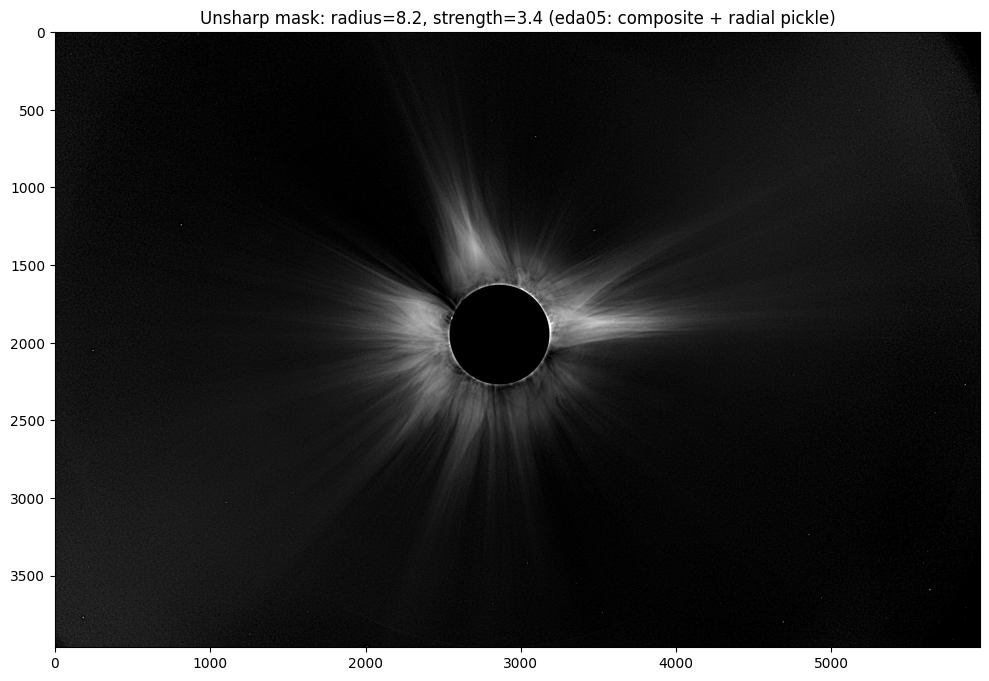

In [6]:
# Load eda04_radial.pkl and convert composite_crop to display using saved mean_at_list, p3_at
import pickle
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

with open(Path(PKL_DIR) / "eda04_radial.pkl", "rb") as fd:
    radial = pickle.load(fd)
mean_at_list = radial["mean_at_list"]
p3_at = radial["p3_at"]
moon_mask = radial["moon_mask"]

assert composite_crop.shape == mean_at_list[0].shape, f"shape mismatch: crop {composite_crop.shape} vs mean_at {mean_at_list[0].shape}"

# Piecewise map (mean/2->0.4, mean->0.4, 2*mean->1) per mean_at, then average (same as eda04)
display_ts = []
for mean_at in mean_at_list:
    valid = np.isfinite(mean_at) & (mean_at > 0)
    out = np.zeros_like(composite_crop, dtype=np.float64)
    v = composite_crop[valid]
    m = mean_at[valid]
    m2 = np.maximum(m / 2.0, 1e-9)
    m1 = np.maximum(m, 1e-9)
    out[valid] = np.where((v > m/2) & (v <= m), 0.4 * (v - m/2) / m2, 0.0)
    out[valid] = np.where((v > m) & (v <= 2*m), 0.4 + 0.6 * (v - m) / m1, out[valid])
    out[valid] = np.where(v > 2*m, 1.0, out[valid])
    display_ts.append(out)
display_t = np.mean(display_ts, axis=0)

# (p3, 1) -> (0, 1)
span = np.maximum(1.0 - p3_at, 1e-9)
display_t = np.clip((display_t - p3_at) / span, 0.0, 1.0)
display_t[moon_mask] = 0.0

# Unsharp mask (same as eda04)
radius = 8.2
strength = 3.4
blurred = gaussian_filter(display_t, sigma=radius, mode="nearest")
sharpened = display_t + strength * (display_t - blurred)
sharpened = np.clip(sharpened, 0.0, 1.0)
sharpened[moon_mask] = 0.0

Image.fromarray((sharpened * 255).clip(0, 255).astype(np.uint8)).save(Path(PKL_DIR) / "eda04_radial_normalize_sharpen.png")
print(f"Saved {Path(PKL_DIR) / 'eda04_radial_normalize_sharpen.png'}")

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.imshow(sharpened, cmap="gray", vmin=0, vmax=1)
ax.set_title("Unsharp mask: radius=8.2, strength=3.4 (eda05: composite + radial pickle)")
plt.tight_layout()
plt.show()